<a href="https://colab.research.google.com/github/YoshnaM/6CS012-Artificial-Intelligence-and-Machine-Learning/blob/main/YoshnaMaharjan_2406791_Worksheet05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Worksheet 05

##Implement an End to End CNN Model for Image Classification Task

##Objective
In this exercise, you will build and train a Convolutional Neural Network to classify fruits in Amazon using TensorFlow and Keras.

###Task 1: Data Understanding and Visualization:
Download the Provided Data and Complete the following task.
1. Load and visualize images from a dataset stored in directories, where each subdirectory represents a class. You are expected to write a code:

    • Get the list of class directories from the train folder.

    • Select one image randomly from each class.

    • Display the images in a grid format with two rows using matplotlib.

In [65]:
from google.colab import drive
import zipfile
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report

In [66]:
zip_path = "/content/drive/MyDrive/Artificial_Intelligence_And_Machine_Learning/FruitinAmazon.zip"
extract_path = "/content/FruitinAmazon"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("ZIP extracted.")
else:
    print("Dataset already extracted.")

Dataset already extracted.


In [67]:
def find_folder(base_dir, target_name):
    for root, dirs, files in os.walk(base_dir):
        if target_name in dirs:
            return os.path.join(root, target_name)
    return None

train_dir = find_folder(extract_path, "train")
test_dir = find_folder(extract_path, "test")

print("Train folder:", train_dir)
print("Test folder:", test_dir)

Train folder: /content/FruitinAmazon/FruitinAmazon/train
Test folder: /content/FruitinAmazon/FruitinAmazon/test


Classes: ['graviola', 'pupunha', 'acai', 'cupuacu', 'guarana', 'tucuma']


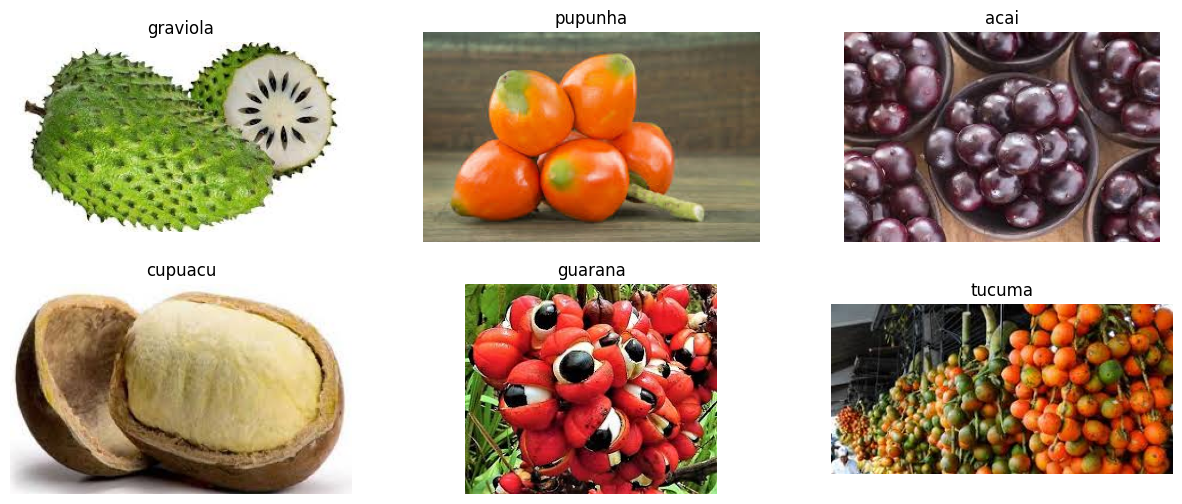

In [68]:
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
print("Classes:", classes)

plt.figure(figsize=(15,6))

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img = Image.open(os.path.join(cls_path, img_name))

    plt.subplot(2, (len(classes)+1)//2, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

2. Check for Corrupted Image: Write a script that verifies whether the image in the train directory are valid. If any corrupted images are found, the script must remove the image from the directory and print the message which image have been removed, if none found print "No Corrupted Images Found."

    • Hint:

    - Iterate through each class subdirectory and check if each image is valid.

    - Use the Image.open() function to attempt to load each image.

    - If the image is corrupted i.e. raises an IOError or SyntaxError, remove the image from the directory and print f"Removed corrupted image: {image_path}".

    - Maintain a list of all corrupted image paths for reporting.

    • Expected Output: No corrupted images found.


In [69]:
corrupted_images = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


##Task 2: Loading and Preprocessing Image Data in keras:
In this section, we will load and preprocess image data from a directory using the image dataset from directory function in Keras. This function is used to load images from a directory structure where subdirectories represent different
classes. We will also apply basic preprocessing, including resizing and batching and normalization of images. The same function can be used to load train and validation data.

In [70]:
# Define image size and batch size
img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2    # 80% training, 20% validation

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255)     # Normalize pixel values to [0, 1]

# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


##Task 3 - Implement a CNN with
###Follow the following Structure and Hyper - parameters:
##Convolutional Architecture:

• Convolutional Layer 1:

- Filter Size (F): (3, 3)

- Number of Filters (k): 32

- Padding (P): same

- Stride (s): 1

• Activation Layer: ReLU activation

• Pooling Layer 1: Max pooling

- Filter Size (F): (2, 2)

- Stride (s): 2

• Convolutional Layer 2:

- Filter Size (F): (3, 3)

- Number of Filters (k): 32

- Padding (P): same

- Stride (s): 1

• Activation Layer: ReLU activation

• Pooling Layer 2: Max pooling

- Filter Size (F): (2, 2)

- Stride (s): 2


##Fully Connected Network Architecture:
• Flatten Layer: Flatten the input coming from the convolutional layers

• Input Layer:

• Hidden Layer - 2:

- Number of Neurons: 64

- Number of Neurons: 128

• Output Layer:

- Number of Neurons: num classes (number of output classes)

In [72]:
num_classes = len(classes)

model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

##Task 4: Compile the Model
###Model Compilation
• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy), and evaluation metric (e.g., accuracy).

In [73]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
earlystop = EarlyStopping(monitor='val_loss', patience=10, verbose=1)

##Task 5: Train the Model
###Model Training
• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs to 250.

• Use val ds for validation.

• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoiding overfitting.

In [74]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.1655 - loss: 1.9682
Epoch 1: val_loss improved from None to 3.51833, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 793ms/step - accuracy: 0.1528 - loss: 2.0585 - val_accuracy: 0.0000e+00 - val_loss: 3.5183
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.1794 - loss: 1.9181
Epoch 2: val_loss improved from 3.51833 to 2.03812, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 788ms/step - accuracy: 0.1944 - loss: 1.9151 - val_accuracy: 0.0000e+00 - val_loss: 2.0381
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.2859 - loss: 1.6451
Epoch 3: val_loss improved from 2.03812 to 1.69704, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 572ms/step - accuracy: 0.2639 - loss: 1.6766 - val_accuracy: 0.2222 - val_loss: 1.6970
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.4502 - loss: 1.5173
Epoch 4: val_loss improved from 1.69704 to 1.64345, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step - accuracy: 0.4444 - loss: 1.5140 - val_accuracy: 0.2222 - val_loss: 1.6434
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.6227 - loss: 1.3022
Epoch 5: val_loss improved from 1.64345 to 1.50497, saving model to best_model.h5


...


Epoch 6: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 492ms/step - accuracy: 0.4444 - loss: 1.1637 - val_accuracy: 0.7778 - val_loss: 0.9734
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.8316 - loss: 0.8388
Epoch 7: val_loss did not improve from 0.97345
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 439ms/step - accuracy: 0.7917 - loss: 0.8543 - val_accuracy: 0.4444 - val_loss: 1.3184
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.8108 - loss: 0.6611
Epoch 8: val_loss improved from 0.97345 to 0.90719, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 648ms/step - accuracy: 0.7917 - loss: 0.6663 - val_accuracy: 0.7778 - val_loss: 0.9072
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.9010 - loss: 0.4437
Epoch 9: val_loss improved from 0.90719 to 0.67561, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 747ms/step - accuracy: 0.8750 - loss: 0.4702 - val_accuracy: 0.8889 - val_loss: 0.6756
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 0.9300 - loss: 0.3336
Epoch 10: val_loss did not improve from 0.67561
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 805ms/step - accuracy: 0.9306 - loss: 0.3373 - val_accuracy: 0.6667 - val_loss: 0.8867
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9398 - loss: 0.2564
Epoch 11: val_loss did not improve from 0.67561
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 489ms/step - accuracy: 0.9444 - loss: 0.2277 - val_accuracy: 0.8333 - val_loss: 0.8930
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.9902 - loss: 0.1445
Epoch 12: val_loss did not improve from 0.67561
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 442ms/step - accuracy: 0.9861 - loss: 0.1523 - val_accuracy: 0.8889 - val_loss: 0.7446
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 1.0000 - loss: 0.0777
Epo


Epoch 14: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 497ms/step - accuracy: 1.0000 - loss: 0.0547 - val_accuracy: 0.7778 - val_loss: 0.6548
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 1.0000 - loss: 0.0358
Epoch 15: val_loss improved from 0.65477 to 0.51134, saving model to best_model.h5



Epoch 15: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step - accuracy: 1.0000 - loss: 0.0370 - val_accuracy: 0.7778 - val_loss: 0.5113
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 1.0000 - loss: 0.0178
Epoch 16: val_loss did not improve from 0.51134
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 435ms/step - accuracy: 1.0000 - loss: 0.0170 - val_accuracy: 0.8889 - val_loss: 0.7101
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 1.0000 - loss: 0.0273
Epoch 17: val_loss did not improve from 0.51134
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 465ms/step - accuracy: 1.0000 - loss: 0.0306 - val_accuracy: 0.8333 - val_loss: 0.7050
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 1.0000 - loss: 0.0048
Epoch 18: val_loss did not improve from 0.51134
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 814ms/step - accuracy: 1.0000 - loss: 0.0057 - val_accuracy: 0.7778 - val_loss: 0.8562
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 1.0000 - loss: 0.0086
Ep

##Task 6: Evaluate the Model
###Model Evaluation
• After training, evaluate the model using model.evaluate() on the test set to check the test accuracy and loss.

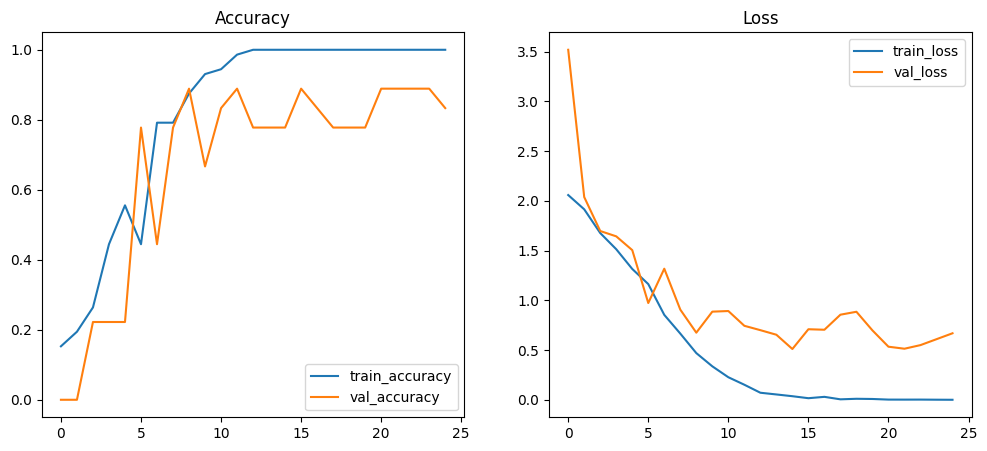

In [76]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')

plt.show()

In [77]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [79]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.6667 - loss: 1.0530
Test Loss: 1.0529885292053223
Test Accuracy: 0.6666666865348816


##Task 7: Save and Load the Model
###Model Saving and Loading
• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [80]:
model.save("final_model.h5")

best_model = load_model("best_model.h5")

best_model.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step - accuracy: 0.7667 - loss: 0.7016


[0.7016316652297974, 0.7666666507720947]

##Task 8: Predictions and Classification Report
###Making Predictions
• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

• Also use from sklearn.metrics import classification report to report the Classification Report of your Model Performance.

In [81]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)

y_pred_prob = best_model.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

report = classification_report(y_true, y_pred, target_names=classes)
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
              precision    recall  f1-score   support

    graviola       0.80      0.80      0.80         5
     pupunha       0.62      1.00      0.77         5
        acai       1.00      1.00      1.00         5
     cupuacu       1.00      0.60      0.75         5
     guarana       0.62      1.00      0.77         5
      tucuma       1.00      0.20      0.33         5

    accuracy                           0.77        30
   macro avg       0.84      0.77      0.74        30
weighted avg       0.84      0.77      0.74        30

